
# 2.2 Boosting（升級版）

這份筆記延續原本的教學脈絡，主軸仍然是：
- AdaBoost
- Gradient Boosting
- Boosting 的核心概念與評估方式

同時補上幾個比較貼近現代 sklearn 使用習慣的地方：
- 使用 `estimator` 取代舊版 `base_estimator`
- 補上 `stratify`、`random_state`
- 使用 `classification_report`、`confusion_matrix` 做模型評估
- 明確區分 AdaBoost 與 Gradient Boosting 的差異



## 這份筆記會回答什麼？

1. Boosting 是什麼？
2. AdaBoost 與 Gradient Boosting 差在哪？
3. 為什麼 Boosting 常被說是「一步一步修正錯誤」？
4. 在 sklearn 裡該怎麼做基本分類實作？


In [2]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


## Boosting 的核心概念

**Boosting** 是一種 **sequential ensemble** 方法：

- 第 1 個模型先做預測
- 後面的模型再去修正前面模型做不好的地方
- 一步一步把整體模型推向更好的結果

可以先用一句話記：

> Bagging 比較像「多個模型一起投票來降低 variance」；  
> Boosting 比較像「一個模型接一個模型修正錯誤來降低 bias」。



## 載入 Iris 資料集

Iris 不是很新的資料集，但它非常適合用來做教學示範：
- 結構乾淨
- 特徵數量少
- 可以先把重點放在模型概念，而不是前處理


In [3]:
iris = datasets.load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="target")

print("target_names:", iris.target_names)
print("X shape:", X.shape)
print("y shape:", y.shape)

pd.concat([X, y], axis=1).head()

target_names: ['setosa' 'versicolor' 'virginica']
X shape: (150, 4)
y shape: (150,)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
y.value_counts().sort_index()

target
0    50
1    50
2    50
Name: count, dtype: int64


## 切分訓練集 / 測試集

這裡補上兩個實務上很常見的習慣：

- `random_state=42`：讓結果可重現
- `stratify=y`：讓 train / test 的類別比例盡量一致


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (105, 4)
X_test : (45, 4)



# 1. AdaBoost

## AdaBoost 在做什麼？

AdaBoost（Adaptive Boosting）的想法是：

- 先訓練一個弱學習器
- 找出哪些樣本比較難分、比較容易分錯
- 後續模型更專注在這些「前面做不好的地方」

在分類問題中，**AdaBoost 常搭配很淺的樹**，像是 `max_depth=1` 的 decision stump。

### 現代 sklearn 提醒
舊教材常看到：
```python
AdaBoostClassifier(base_estimator=...)
```
現在新版較常用：
```python
AdaBoostClassifier(estimator=...)
```


In [6]:
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

ada_model.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


In [7]:
ada_train_pred = ada_model.predict(X_train)
ada_test_pred = ada_model.predict(X_test)

print("AdaBoost training accuracy:", round(accuracy_score(y_train, ada_train_pred), 4))
print("AdaBoost test accuracy    :", round(accuracy_score(y_test, ada_test_pred), 4))

AdaBoost training accuracy: 1.0
AdaBoost test accuracy    : 0.9333


In [9]:
print("AdaBoost classification report")
print(classification_report(y_test, ada_test_pred, target_names=iris.target_names))

AdaBoost classification report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



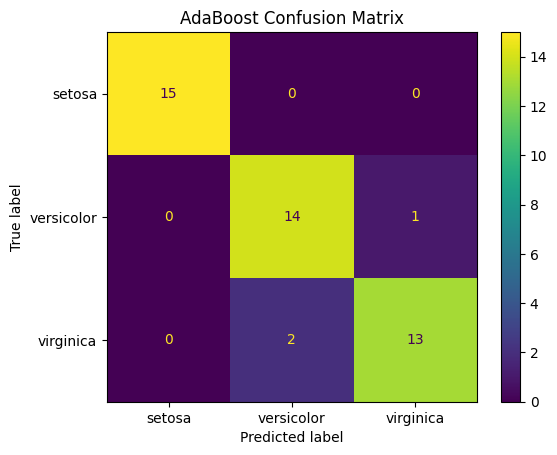

In [10]:
cm = confusion_matrix(y_test, ada_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot()
plt.title("AdaBoost Confusion Matrix")
plt.show()


## AdaBoost 的特徵重要性

樹模型家族通常可以提供 `feature_importances_`。  
這能幫助我們快速看到模型「相對依賴哪些特徵」。

注意：
- 它反映的是模型的分裂偏好，而不是因果關係
- 也不等於特徵越重要就一定越值得相信
- 對於高基數或相關特徵可能有偏誤
- 只能視為模型內部使用特徵的一種線索

在實務中，建議搭配「Permutation Importance」一起使用，
從模型外部驗證特徵對預測的實際影響。

In [24]:
ada_importances = pd.Series(ada_model.feature_importances_, index=X.columns).sort_values()
ada_importances

sepal length (cm)    0.051810
sepal width (cm)     0.123910
petal width (cm)     0.401230
petal length (cm)    0.423049
dtype: float64

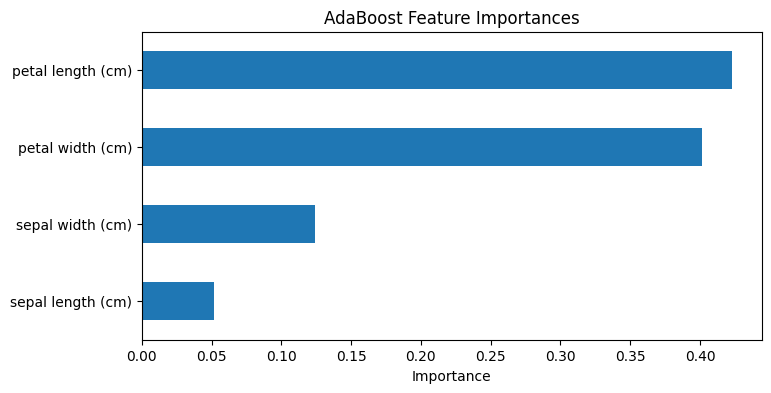

In [25]:
ax = ada_importances.plot(kind="barh", figsize=(8, 4))
ax.set_title("AdaBoost Feature Importances")
ax.set_xlabel("Importance")
plt.show()


# 2. Gradient Boosting

## Gradient Boosting 和 AdaBoost 差在哪？

兩者都屬於 Boosting，但修正錯誤的方式不同：

| 方法 | 核心想法 | 直覺理解 |
|---|---|---|
| AdaBoost | 提高分錯樣本的重要性 | 叫後面的模型更重視難分樣本 |
| Gradient Boosting | 沿著 loss function 的方向逐步修正 | 每一步都在學「前一步還沒學好的殘差 / 錯誤」 |

所以很多人會說：
- **AdaBoost 比較像在調整樣本權重**
- **Gradient Boosting 比較像在用梯度修正誤差**


In [13]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [14]:
gb_train_pred = gb_model.predict(X_train)
gb_test_pred = gb_model.predict(X_test)

print("Gradient Boosting training accuracy:", round(accuracy_score(y_train, gb_train_pred), 4))
print("Gradient Boosting test accuracy    :", round(accuracy_score(y_test, gb_test_pred), 4))

Gradient Boosting training accuracy: 1.0
Gradient Boosting test accuracy    : 0.9333


In [15]:
print("Gradient Boosting classification report")
print(classification_report(y_test, gb_test_pred, target_names=iris.target_names))

Gradient Boosting classification report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



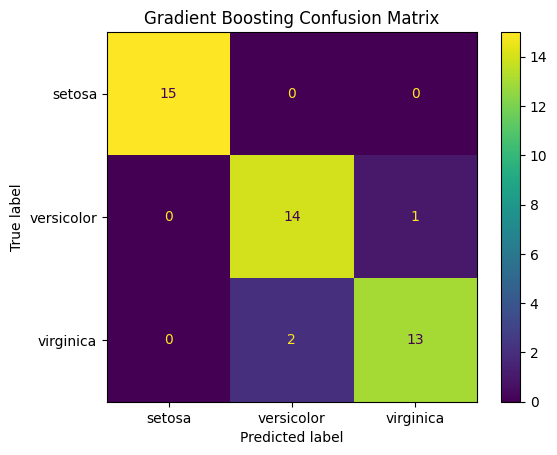

In [16]:
cm = confusion_matrix(y_test, gb_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot()
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

In [26]:
gb_importances = pd.Series(gb_model.feature_importances_, index=X.columns).sort_values()
gb_importances

sepal width (cm)     0.011320
sepal length (cm)    0.013937
petal length (cm)    0.311066
petal width (cm)     0.663676
dtype: float64

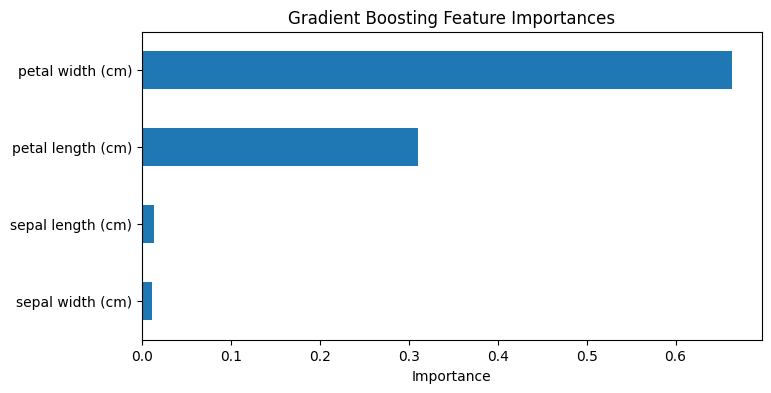

In [27]:
ax = gb_importances.plot(kind="barh", figsize=(8, 4))
ax.set_title("Gradient Boosting Feature Importances")
ax.set_xlabel("Importance")
plt.show()


# 3. 結果比較

下面把兩個模型的結果整理成表格，比較直觀。


In [28]:
comparison = pd.DataFrame({
    "Model": ["AdaBoost", "Gradient Boosting"],
    "Train Accuracy": [accuracy_score(y_train, ada_train_pred), accuracy_score(y_train, gb_train_pred)],
    "Test Accuracy": [accuracy_score(y_test, ada_test_pred), accuracy_score(y_test, gb_test_pred)]
})

comparison

,Model,Train Accuracy,Test Accuracy
0,AdaBoost,1.0,0.933333
1,Gradient Boosting,1.0,0.933333


## 怎麼解讀這個結果？

可以觀察幾件事：

1. **訓練分數是否明顯高於測試分數**  
   如果差距很大，要小心 overfitting。

2. **兩個模型誰的 test score 比較穩**  
   真正比較模型時，重點通常不是 train score，而是 test / validation 表現。

3. **Iris 太簡單時，模型差距可能不會很大**  
   這是資料集本身的特性，不代表兩個模型在真實專案中差異也這麼小。


# 4. Boosting 的重點整理

## Bias / Variance 角度

- **Bagging**：主要降低 **variance**
- **Boosting**：主要降低 **bias**，但有時也可能提高 variance

## 為什麼 Boosting 容易 overfit？

因為它會持續修正前面沒做好的部分。  
如果資料裡有很多噪音，模型可能會連噪音也一起認真學進去。

## 一句話總結

> Boosting 是一種把多個弱學習器按順序串起來、逐步修正錯誤的集成方法。



# 5. 現代實務延伸

在現代資料科學與機器學習實務中，談到 Boosting 時，常常還會延伸到：

- XGBoost
- LightGBM
- CatBoost

這些方法可以視為更工程化、更強化版的 gradient boosting。

不過在學習順序上，**先把 AdaBoost 與 Gradient Boosting 的核心觀念搞懂**，再去學 XGBoost / LightGBM 會更穩。


In [29]:
# 這格先不執行，作為延伸閱讀參考
# 若環境已安裝 xgboost，可以取消註解試試看

from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric="mlogloss"
)
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

## 你可以帶走的觀念

- AdaBoost：更像是「加強關注分錯樣本」
- Gradient Boosting：更像是「沿著損失函數方向逐步修正」
- AdaBoost 的 learning rate 是 scaling weak learner weights（縮放模型權重，通常設定0.5\~1.0）
- Gradient Boosting 的 learning rate 是 shrinkage parameter，控制每一步更新幅度，所以通常需要設得比較小(0.01\~0.1)  
    較小的 learning_rate + 較多的 n_estimators  
    → 通常會有更好的泛化能力（但訓練較慢）
- Boosting 通常比單一淺模型強，但也更需要留意 overfitting
- 在現代實務中，XGBoost / LightGBM 很常見，但基礎仍是這裡學的觀念